# Pontificia Universidad Católica de Chile

# EPG4001 Aprendizaje Supervisado

# Material Complementario

# Clase4MIAApSup.pdf

**Jorge Luis Bazán**  
**jlbazan@uc.cl**


# Librerías

Las librerías a utilizar para los procedimientos son las siguientes:


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import io
import shutil
import subprocess

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cargar_rdataset(nombre, paquete):
    try:
        return sm.datasets.get_rdataset(nombre, paquete).data
    except Exception as py_err:
        if shutil.which("Rscript") is None:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python y Rscript no está disponible."
            ) from py_err

        r_code = f'''
        pkg <- "{paquete}"
        ds <- "{nombre}"
        if (pkg != "datasets" && !requireNamespace(pkg, quietly = TRUE)) {{
          install.packages(pkg, repos = "https://cloud.r-project.org")
        }}
        data(list = ds, package = pkg, envir = environment())
        write.csv(as.data.frame(get(ds)), row.names = FALSE)
        '''
        res = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True)
        if res.returncode != 0:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python ni con R.\n{res.stderr}"
            ) from py_err
        return pd.read_csv(io.StringIO(res.stdout))

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

EPS = 1e-15

# 1. Regresión Logística: Default

## 1.1. Base de datos

La base `Default` contiene información de **10,000 clientes** de tarjetas de crédito. El objetivo es predecir si un cliente incurrirá en **default** (impago): $y_i \in \{0, 1\}$.

Cargando y explorando la data:


In [ ]:
Default = cargar_rdataset("Default", "ISLR")
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [ ]:
Default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [ ]:
dist_default = (
    Default["default"]
    .value_counts()
    .rename_axis("default")
    .reset_index(name="n")
)
dist_default["proporcion"] = (dist_default["n"] / dist_default["n"].sum()).round(3)
dist_default

,default,n,proporcion
0,No,9667,0.967
1,Yes,333,0.033


Vemos que la data está desbalanceada, siendo solo el 3.3% casos de impago.


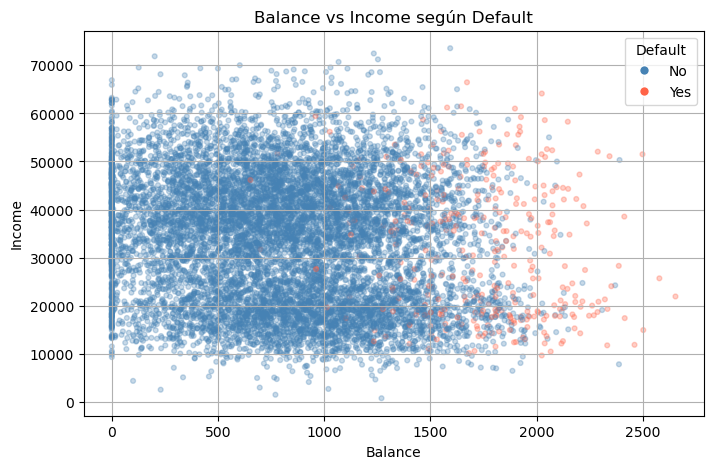

In [ ]:
colors = Default["default"].map({"No": "steelblue", "Yes": "tomato"})

fig, ax = plt.subplots()
ax.scatter(Default["balance"], Default["income"], c=colors, alpha=0.3, s=12)
ax.set_xlabel("Balance")
ax.set_ylabel("Income")
ax.set_title("Balance vs Income según Default")

handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="No", markerfacecolor="steelblue", markersize=7),
    plt.Line2D([0], [0], marker="o", color="w", label="Yes", markerfacecolor="tomato", markersize=7),
]
ax.legend(handles=handles, title="Default")
plt.show()

A partir del scatterplot entre Balance e Income no se ven patrones fuertes de relación entre estas variables. Sí observamos que quienes incurren en default se agrupan en valores mayores de Balance.


## 1.2. Ajuste del modelo de Regresión Logística

El modelo logístico es:

\begin{align*}
  y_i &\sim \text{Bernoulli}(\pi_i) \\
  \text{logit}(\pi_i) &= \beta_0 + \beta_1\, \texttt{balance}_i +
  \beta_2\, \texttt{income}_i + \beta_3\, \texttt{student}_i
\end{align*}

Traspasando los valores de la variable a 0 y 1:


In [ ]:
Default = Default.copy()
Default["default_bin"] = np.where(Default["default"] == "Yes", 1, 0)
Default.head()

,default,student,balance,income,default_bin
0,No,No,729.526495,44361.625074,0
1,No,Yes,817.180407,12106.134700,0
2,No,No,1073.549164,31767.138947,0
3,No,No,529.250605,35704.493935,0
4,No,No,785.655883,38463.495879,0


Ajustamos el modelo con un modelo lineal generalizado binomial y obtenemos un resumen de sus resultados:


In [ ]:
modelo_logit = smf.glm(
    "default_bin ~ balance + income + C(student)",
    data=Default,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
).fit()

print(modelo_logit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_bin   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -785.77
Date:                Mon, 06 Jul 2026   Deviance:                       1571.5
Time:                        09:03:39   Pearson chi2:                 7.00e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1262
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -10.8690      0.49

Vemos que en términos de significancia las variables balance y si el sujeto es o no estudiante resultan significativas con un 95% de confianza para realizar las predicciones.


## 1.2.1 Clasificación y Matriz de Confusión

Obtenemos primero las probabilidades predichas por el modelo y a partir de ellas catalogamos a cada sujeto considerando primeramente un threshold de 0.5.


In [ ]:
y = Default["default_bin"].to_numpy()
pi_hat = modelo_logit.fittedvalues.to_numpy()
y_pred = np.where(pi_hat >= 0.5, "Yes", "No")

A partir de estas clasificaciones obtenemos ya la matriz de confusión.


In [ ]:
conf_mat = pd.DataFrame(
    confusion_matrix(Default["default"], y_pred, labels=["No", "Yes"]),
    index=["Real No", "Real Yes"],
    columns=["Predicho No", "Predicho Yes"],
)
conf_mat

,Predicho No,Predicho Yes
Real No,9627,40
Real Yes,228,105


In [ ]:
print("Accuracy:", round(accuracy_score(Default["default"], y_pred), 4))
print("Precision:", round(precision_score(Default["default"], y_pred, pos_label="Yes"), 4))
print("Recall/Sensibilidad:", round(recall_score(Default["default"], y_pred, pos_label="Yes"), 4))
print("F1:", round(f1_score(Default["default"], y_pred, pos_label="Yes"), 4))

Accuracy: 0.9732
Precision: 0.7241
Recall/Sensibilidad: 0.3153
F1: 0.4393


## 1.2.2. F1 Score

Podemos calcular el F1 Score para el modelo ajustado:

$$F_1 = \frac{2VP}{2VP + FP + FN}$$


In [ ]:
tn, fp, fn, tp = confusion_matrix(Default["default"], y_pred, labels=["No", "Yes"]).ravel()
f1_manual = 2 * tp / (2 * tp + fp + fn)
print("F1 Score:", round(f1_manual, 4))

F1 Score: 0.4393


Usando métricas equivalentes a la librería *Metrics*:


In [ ]:
precision_val = precision_score(y, (y_pred == "Yes").astype(int))
recall_val = recall_score(y, (y_pred == "Yes").astype(int))
specificity_val = tn / (tn + fp)

print("Precision:", round(precision_val, 4))
print("Sensibilidad:", round(recall_val, 4))
print("Especificidad:", round(specificity_val, 4))

Precision: 0.7241
Sensibilidad: 0.3153
Especificidad: 0.9959


Vemos que, empleando un threshold de 0.5, la precisión resultó ser cercana a 0.72, mucho mejor que la sensibilidad cercana a 0.32. Esto sería indicio de que el modelo tiene mejor desempeño cuando clasifica casos de default que al recuperar todos los verdaderos casos de default. Podemos obtener la curva ROC y el threshold óptimo:


Umbral óptimo:  0.0312
Sensibilidad:   0.9039
Especificidad:  0.8612


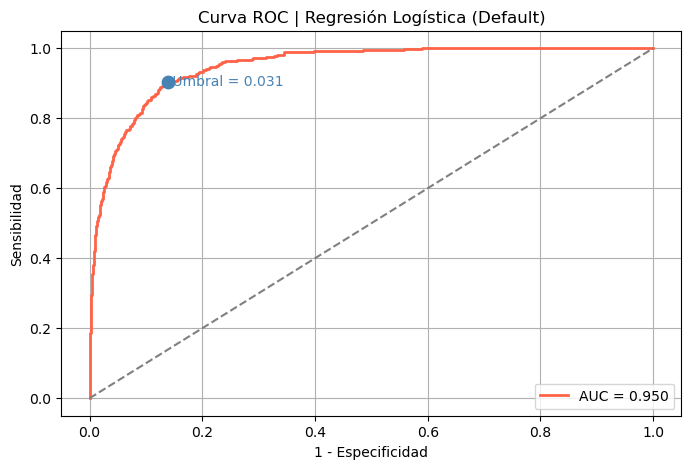

In [ ]:
fpr, tpr, thresholds = roc_curve(y, pi_hat)
auc_logit = roc_auc_score(y, pi_hat)

youden = tpr - fpr
best_idx = np.argmax(youden)
coords_opt = {
    "threshold": thresholds[best_idx],
    "sensitivity": tpr[best_idx],
    "specificity": 1 - fpr[best_idx],
}

print("Umbral óptimo: ", round(coords_opt["threshold"], 4))
print("Sensibilidad:  ", round(coords_opt["sensitivity"], 4))
print("Especificidad: ", round(coords_opt["specificity"], 4))

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color="tomato", linewidth=2, label=f"AUC = {auc_logit:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.scatter(fpr[best_idx], tpr[best_idx], color="steelblue", s=80, zorder=3)
ax.text(
    fpr[best_idx],
    tpr[best_idx],
    f" Umbral = {coords_opt['threshold']:.3f}",
    color="steelblue",
    va="center",
)
ax.set_xlabel("1 - Especificidad")
ax.set_ylabel("Sensibilidad")
ax.set_title("Curva ROC | Regresión Logística (Default)")
ax.legend(loc="lower right")
plt.show()

El AUC resultante es cercano a 0.95. Para el punto óptimo, el modelo clasificará a los sujetos como "default" para valores de probabilidad sobre aproximadamente 0.031, y con este punto de corte se obtiene una sensibilidad cercana a 0.9 y especificidad cercana a 0.86.

A continuación, considerando como función de pérdida la Devianza media ($L(Y,f(\cdot))=D/n = -2\log(\hat{p}_{Y})/n=-2\ell/n$), de esta manera los resultados obtenidos por los distintos métodos serán comparables. Realizando las estimaciones:


## 1.3.1. Validación Cruzada Simple

Dividimos el conjunto de datos en **70% entrenamiento** y **30% prueba**; para esto seleccionamos aleatoriamente los casos y separamos la base en `train_d` y `test_d`.


In [ ]:
train_d, test_d = train_test_split(Default, train_size=0.7, random_state=123, stratify=Default["default"])
train_d.shape, test_d.shape

((7000, 5), (3000, 5))

Ajustamos el modelo con la data de entrenamiento:


In [ ]:
mod_hold = smf.glm(
    "default_bin ~ balance + income + C(student)",
    data=train_d,
    family=sm.families.Binomial(),
).fit()

Predecimos y evaluamos con la data de test:


In [ ]:
pi_hold = mod_hold.predict(test_d)
y_hold = np.where(pi_hold >= 0.5, "Yes", "No")

print("Accuracy:", round(accuracy_score(test_d["default"], y_hold), 4))
print("F1 Score:", round(f1_score(test_d["default"], y_hold, pos_label="Yes"), 4))

Accuracy: 0.9753
F1 Score: 0.4789


Vemos que utilizando validación cruzada simple se obtiene un puntaje F1 Score y accuracy similares a los reportados para la partición hold-out.


## 1.3.2. Validación Cruzada K-Fold

En Python podemos realizar K-Fold con `StratifiedKFold`, manteniendo la proporción de casos Default en cada pliegue. Dividimos el conjunto en **K = 10 pliegues**.


In [ ]:
def mean_deviance(y_true, p):
    p = np.clip(np.asarray(p), EPS, 1 - EPS)
    y_true = np.asarray(y_true)
    return -2 * np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
kfold_rows = []

for fold, (train_idx, test_idx) in enumerate(skf.split(Default, Default["default_bin"]), start=1):
    train_fold = Default.iloc[train_idx]
    test_fold = Default.iloc[test_idx]
    mod_fold = smf.glm(
        "default_bin ~ balance + income + C(student)",
        data=train_fold,
        family=sm.families.Binomial(),
    ).fit()
    p_fold = mod_fold.predict(test_fold)
    pred_fold = (p_fold >= 0.5).astype(int)
    y_fold = test_fold["default_bin"].to_numpy()
    tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_fold, pred_fold, labels=[0, 1]).ravel()
    kfold_rows.append({
        "Fold": fold,
        "ROC": roc_auc_score(y_fold, p_fold),
        "Sens": recall_score(y_fold, pred_fold, zero_division=0),
        "Spec": tn_f / (tn_f + fp_f),
        "MeanDeviance": mean_deviance(y_fold, p_fold),
    })

kfold_res = pd.DataFrame(kfold_rows)
kfold_res

,Fold,ROC,Sens,Spec,MeanDeviance
0,1,0.952085,0.272727,0.996898,0.147047
1,2,0.944063,0.303030,0.997932,0.164221
2,3,0.979850,0.424242,0.996898,0.123908
3,4,0.962207,0.393939,0.996898,0.139894
4,5,0.967347,0.303030,0.995863,0.139942
5,6,0.925982,0.242424,0.994829,0.188110
6,7,0.934286,0.363636,0.990693,0.174779
7,8,0.950158,0.411765,0.997930,0.153843
8,9,0.944099,0.176471,0.995859,0.170758
9,10,0.935178,0.294118,0.993789,0.175588


In [ ]:
print("Promedios K-Fold:")
kfold_res[["ROC", "Sens", "Spec", "MeanDeviance"]].mean().round(4)

Promedios K-Fold:


ROC             0.9495
Sens            0.3185
Spec            0.9958
MeanDeviance    0.1578
dtype: float64

La devianza media con validación cruzada K-Fold resulta cercana a 0.15, en línea con lo esperado para este modelo.


## 1.3.3. Validación Cruzada Aleatoria (Bootstrap)

Se consideran tres estimadores del error de predicción.

### 1.3.3.1. Estimador Bootstrap estándar

Si $\hat{f}^{*b}(x_i)$ es el valor predicho a partir del modelo ajustado al $b$-ésimo conjunto bootstrap, el estimador del error es:

$$\widehat{\text{Err}}_{boot} =
  \frac{1}{B}\frac{1}{N}\sum_{b=1}^{B}\sum_{i=1}^{N}
  L\!\left(y_i,\, \hat{f}^{*b}(x_i)\right)$$

Seteamos semilla y definimos el número de muestras bootstrap:


In [ ]:
rng = np.random.default_rng(42)
B = 200
n = len(Default)

Aplicamos el método ajustando el modelo logístico:


In [ ]:
err_boot_std = []

for _ in range(B):
    idx_b = rng.choice(n, size=n, replace=True)
    train_b = Default.iloc[idx_b]
    mod_b = smf.glm(
        "default_bin ~ balance + income + C(student)",
        data=train_b,
        family=sm.families.Binomial(),
    ).fit()
    p_b = mod_b.predict(Default)
    err_boot_std.append(mean_deviance(Default["default_bin"], p_b))

err_boot_std = np.array(err_boot_std)
print("Err_boot Deviance (estándar):", round(err_boot_std.mean(), 4))
print("SD:                          ", round(err_boot_std.std(ddof=1), 4))

Err_boot Deviance (estándar): 0.1576
SD:                           0.0003


### 1.3.3.2. Estimador Leave-One-Out Bootstrap $\widehat{\text{Err}}^{(1)}$

Para corregir el sesgo, se evalúa cada observación $i$ **solo** en las muestras bootstrap que **no** la contienen:

$$\widehat{\text{Err}}^{(1)} =
  \frac{1}{N}\sum_{i=1}^{N}
  \frac{1}{|C^{(-i)}|}\sum_{b\in C^{(-i)}}
  L\!\left(y_i,\, \hat{f}^{*b}(x_i)\right)$$

donde $C^{(-i)}$ es el conjunto de muestras bootstrap que no incluyen $i$.


In [ ]:
rng = np.random.default_rng(42)
B = 200

preds_matrix = np.full((n, B), np.nan)
in_bag = np.zeros((n, B), dtype=bool)

for b in range(B):
    idx_b = rng.choice(n, size=n, replace=True)
    in_bag[idx_b, b] = True
    mod_b = smf.glm(
        "default_bin ~ balance + income + C(student)",
        data=Default.iloc[idx_b],
        family=sm.families.Binomial(),
    ).fit()
    preds_matrix[:, b] = mod_b.predict(Default)

loo_errors = []
y_all = Default["default_bin"].to_numpy()

for i in range(n):
    oob = ~in_bag[i, :]
    if not np.any(oob):
        loo_errors.append(np.nan)
        continue
    p_oob = np.clip(preds_matrix[i, oob], EPS, 1 - EPS)
    err_i = -2 * (y_all[i] * np.log(p_oob) + (1 - y_all[i]) * np.log(1 - p_oob))
    loo_errors.append(np.mean(err_i))

err_loo = np.nanmean(loo_errors)
print("Err^(1) LOO Deviance:", round(err_loo, 4))

Err^(1) LOO Deviance: 0.1584


### 1.3.3.3. Estimador 0.632 Bootstrap $\widehat{\text{Err}}^{(0.632)}$

Para corregir el sesgo de $\widehat{\text{Err}}^{(1)}$, se pondera con el error aparente $\overline{\text{err}}$ (error en entrenamiento completo):

$$\widehat{\text{Err}}^{(0.632)} =
  0.368\cdot\overline{\text{err}} + 0.632\cdot\widehat{\text{Err}}^{(1)}$$


In [ ]:
err_apparent = modelo_logit.deviance / n
err_632 = 0.368 * err_apparent + 0.632 * err_loo

print("Deviance aparente (err_bar):  ", round(err_apparent, 4))
print("Err^(1) LOO Deviance:         ", round(err_loo, 4))
print("Err^(0.632) Deviance:         ", round(err_632, 4))

Deviance aparente (err_bar):   0.1572
Err^(1) LOO Deviance:          0.1584
Err^(0.632) Deviance:          0.158


## 1.3.4. Función directa tipo `cv.glm` (K-Fold desde GLM)

En Python replicamos la lógica de `boot::cv.glm` usando particiones LOOCV y 10-Fold con la devianza como función de costo.


In [ ]:
def cv_glm_deviance(data, k, random_state=123):
    if k == len(data):
        splitter = KFold(n_splits=k, shuffle=False)
    else:
        splitter = KFold(n_splits=k, shuffle=True, random_state=random_state)
    errors = []
    for train_idx, test_idx in splitter.split(data):
        train_cv = data.iloc[train_idx]
        test_cv = data.iloc[test_idx]
        mod_cv = smf.glm(
            "default_bin ~ balance + income + C(student)",
            data=train_cv,
            family=sm.families.Binomial(),
        ).fit()
        p_cv = mod_cv.predict(test_cv)
        errors.append(mean_deviance(test_cv["default_bin"], p_cv))
    return np.mean(errors)

# LOOCV puede tardar porque ajusta n modelos. Se deja listo para ejecutar si se desea.
# cv_loocv_raw = cv_glm_deviance(Default, len(Default))
cv_10fold_raw = cv_glm_deviance(Default, 10)

print("cv.glm 10-Fold - delta[1] (raw):", round(cv_10fold_raw, 4))

cv.glm 10-Fold - delta[1] (raw): 0.1579


Vemos que los distintos criterios arrojan valores de errores de predicción medios similares, cercanos a una devianza media de 0.15.


# 2. Regresión Múltiple

## 2.1. Base de datos: `Advertising`

La base `Advertising` contiene datos de **200 mercados**. El objetivo es predecir `sales` (ventas) a partir del gasto en publicidad en TV, Radio y Newspaper.


In [ ]:
Advertising = pd.read_csv(
    "https://www.statlearning.com/s/Advertising.csv",
    index_col=0,
)
Advertising.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [ ]:
Advertising.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


## 2.1. Ajuste del modelo

El modelo a probar es:

$$\texttt{sales}_i = \beta_0 + \beta_1\,\texttt{TV}_i +
  \beta_2\,\texttt{radio}_i + \beta_3\,\texttt{newspaper}_i + \varepsilon_i$$

Ajustando el modelo:


In [ ]:
modelo_lm = smf.ols("sales ~ TV + radio + newspaper", data=Advertising).fit()
print(modelo_lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.58e-96
Time:                        09:04:00   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.0

Podemos considerar las funciones de pérdida MAE, MSE y RMSE; además, como desempeño, el $R^{2}$:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2,
\qquad \text{RMSE} = \sqrt{\text{MSE}}$$


In [ ]:
y_hat_lm = modelo_lm.fittedvalues
y_obs = Advertising["sales"]

mse_lm = mean_squared_error(y_obs, y_hat_lm)
rmse_lm = np.sqrt(mse_lm)
mae_lm = mean_absolute_error(y_obs, y_hat_lm)
r2_lm = r2_score(y_obs, y_hat_lm)

print("MSE: ", round(mse_lm, 4))
print("RMSE:", round(rmse_lm, 4))
print("MAE: ", round(mae_lm, 4))
print("R²:  ", round(r2_lm, 4))

MSE:  2.7841
RMSE: 1.6686
MAE:  1.252
R²:   0.8972


## 2.3. Validación Cruzada

Aplicando los criterios vistos en el curso podemos estimar el error de predicción mediante validación cruzada con los distintos criterios.

### 2.3.1. Validación Cruzada Simple

Separamos la base aleatoriamente; nuevamente consideramos 70% de los datos para entrenamiento:


In [ ]:
train_ad, test_ad = train_test_split(Advertising, train_size=0.7, random_state=123)
train_ad.shape, test_ad.shape

((140, 4), (60, 4))

Ajustamos con la data de entrenamiento:


In [ ]:
mod_hold_lm = smf.ols("sales ~ TV + radio + newspaper", data=train_ad).fit()

Estimamos el error de predicción y medimos el desempeño con la data de test:


In [ ]:
y_pred_hold = mod_hold_lm.predict(test_ad)

print("--- Hold-Out 70/30 ---")
print("RMSE:", round(np.sqrt(mean_squared_error(test_ad["sales"], y_pred_hold)), 4))
print("MAE: ", round(mean_absolute_error(test_ad["sales"], y_pred_hold), 4))
print("R²:  ", round(np.corrcoef(test_ad["sales"], y_pred_hold)[0, 1] ** 2, 4))

--- Hold-Out 70/30 ---
RMSE: 1.4472
MAE:  1.156
R²:   0.9237


### 2.3.2. Validación Cruzada K-Fold

Para esta estimación empleamos una validación cruzada con $K=10$ pliegues.


In [ ]:
X_ad = Advertising[["TV", "radio", "newspaper"]]
y_ad = Advertising["sales"]

kf_ad = KFold(n_splits=10, shuffle=True, random_state=123)
lm_sklearn = LinearRegression()

kfold_lm_rows = []
for fold, (train_idx, test_idx) in enumerate(kf_ad.split(X_ad), start=1):
    lm_sklearn.fit(X_ad.iloc[train_idx], y_ad.iloc[train_idx])
    pred_fold = lm_sklearn.predict(X_ad.iloc[test_idx])
    obs_fold = y_ad.iloc[test_idx]
    kfold_lm_rows.append({
        "Fold": fold,
        "RMSE": np.sqrt(mean_squared_error(obs_fold, pred_fold)),
        "Rsquared": r2_score(obs_fold, pred_fold),
        "MAE": mean_absolute_error(obs_fold, pred_fold),
    })

kfold_lm_res = pd.DataFrame(kfold_lm_rows)
kfold_lm_res

,Fold,RMSE,Rsquared,MAE
0,1,1.597301,0.891481,1.196166
1,2,1.390572,0.946244,1.122406
2,3,1.357399,0.888682,1.157088
3,4,2.351343,0.780728,1.403864
4,5,2.105913,0.826963,1.552057
5,6,1.358230,0.898635,1.130906
6,7,1.786305,0.839056,1.451960
7,8,1.697167,0.913205,1.459197
8,9,1.423360,0.889228,1.058351
9,10,1.657098,0.930694,1.290984


In [ ]:
print("Promedios K-Fold:")
kfold_lm_res[["RMSE", "Rsquared", "MAE"]].mean().round(4)

Promedios K-Fold:


RMSE        1.6725
Rsquared    0.8805
MAE         1.2823
dtype: float64

### 2.3.3. Validación Cruzada Aleatoria (Bootstrap)

Seteamos semilla y cantidad de muestras bootstrap ($B=200$):


In [ ]:
rng_lm = np.random.default_rng(42)
B_lm = 200
n_ad = len(Advertising)

Calculamos los errores mediante validación cruzada bootstrap y promediamos:


In [ ]:
err_boot_lm = []

for _ in range(B_lm):
    idx_b = rng_lm.choice(n_ad, size=n_ad, replace=True)
    train_b = Advertising.iloc[idx_b]
    mod_b = smf.ols("sales ~ TV + radio + newspaper", data=train_b).fit()
    y_pred_b = mod_b.predict(Advertising)
    err_boot_lm.append(mean_squared_error(Advertising["sales"], y_pred_b))

print("Err_boot RMSE (estándar):", round(np.sqrt(np.mean(err_boot_lm)), 4))

Err_boot RMSE (estándar): 1.6937


Podemos ver que el error medio predicho es ligeramente mayor en este caso que en los anteriores; sin embargo sabemos que este valor presenta sesgo, podemos corregir esto empleando Bootstrap 0.632.

### 2.3.4. Estimador 0.632 $\widehat{\text{Err}}^{(0.632)}$

El estimador $\widehat{\text{Err}}^{(0.632)}$ corrige el sesgo del bootstrap:

$$\widehat{\text{Err}}^{(0.632)} = 0.368\cdot\overline{\text{err}} + 
0.632\cdot\widehat{\text{Err}}^{(1)}$$

Implementamos este estimador de forma directa en Python.


In [ ]:
rng_lm = np.random.default_rng(42)
preds_lm = np.full((n_ad, B_lm), np.nan)
in_bag_lm = np.zeros((n_ad, B_lm), dtype=bool)

for b in range(B_lm):
    idx_b = rng_lm.choice(n_ad, size=n_ad, replace=True)
    in_bag_lm[idx_b, b] = True
    train_b = Advertising.iloc[idx_b]
    mod_b = smf.ols("sales ~ TV + radio + newspaper", data=train_b).fit()
    preds_lm[:, b] = mod_b.predict(Advertising)

oob_mse = []
y_sales = Advertising["sales"].to_numpy()

for i in range(n_ad):
    oob = ~in_bag_lm[i, :]
    if not np.any(oob):
        oob_mse.append(np.nan)
    else:
        oob_mse.append(np.mean((y_sales[i] - preds_lm[i, oob]) ** 2))

err_loo_lm = np.nanmean(oob_mse)
err_apparent_lm = mean_squared_error(y_sales, modelo_lm.fittedvalues)
err_632_lm = 0.368 * err_apparent_lm + 0.632 * err_loo_lm

print("--- Bootstrap 0.632 ---")
print("RMSE:", round(np.sqrt(err_632_lm), 4))
print("MSE: ", round(err_632_lm, 4))

--- Bootstrap 0.632 ---
RMSE: 1.7187
MSE:  2.954


Vemos que realizando la corrección el error de predicción aumenta respecto del error aparente, lo que es consistente con la idea de estimar desempeño fuera de muestra. Se puede también calcular MAE y R2


# 3. Ejercicios Propuestos

**Ejercicio 1.** Considere la base de datos `Weekly`, la cual contiene 1089 observaciones semanales del mercado bursátil estadounidense entre 1990 y 2010. La variable de interés es `Direction`, que indica si el mercado subió (`Up`) o bajó (`Down`) en una semana determinada, en función de los retornos porcentuales rezagados `Lag1`, `Lag2`, `Lag3`, `Lag4`, `Lag5` y el volumen de transacciones `Volume`.

Proponga y ajuste un modelo de regresión logística, reporte las métricas de desempeño (Accuracy, Sensibilidad, Especificidad, F1 Score y AUC) y estime el error de predicción mediante validación cruzada simple, K-Fold con $K=10$ y bootstrap $\widehat{\text{Err}}^{(0.632)}$.

**Ejercicio 2.** Considere la base de datos `Auto`, la cual contiene información de 392 vehículos. La variable de interés es `mpg` (millas por galón), en función de `horsepower`, `weight`, `acceleration` y `year`. Proponga y ajuste un modelo de regresión múltiple, reporte las métricas de desempeño (RMSE, MAE y $R^2$) y estime el error de predicción mediante validación cruzada simple, K-Fold con $K=10$ y bootstrap $\widehat{\text{Err}}^{(0.632)}$.


# Bibliografía

- Gareth James, Daniela Witten, Trevor Hastie and Robert Tibshirani (2021). *An Introduction to Statistical Learning with Applications in R*, 2nd edition. Springer Series in Statistics.
- Trevor Hastie, Robert Tibshirani and Jerome Friedman (2008). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*. Springer Series in Statistics.
